# Modelo Lineal: Regresión Ridge

La regresión Ridge es el primer modelo de la comparación. Actúa como referencia interpretable frente a los modelos no lineales posteriores. Su objetivo es comprobar si una relación lineal entre las variables de planificación y el ratio mejora la estimación del ERP.

Ridge es una regresión lineal con una penalización sobre el tamaño de los coeficientes (Hoerl y Kennard, 1970):

$$\min_{\beta} \sum_{i}(y_i - \hat{y}_i)^2 + \alpha \sum_{j}\beta_j^2$$

El primer término mide el error de ajuste. El segundo penaliza los coeficientes grandes. El parámetro $\alpha$ regula la intensidad de la penalización: con $\alpha = 0$ equivale a una regresión lineal ordinaria.

Para mi problema las variables de entrada presentan una estructura jerárquica. Cada máquina pertenece a una única familia de máquinas. Cada familia de producto pertenece a una única línea de producto. Tras la codificación one-hot, parte de las columnas pueden resultar redundantes entre sí.

Esta redundancia genera multicolinealidad. En una regresión ordinaria, provoca coeficientes inestables y de gran magnitud. La penalización de Ridge estabiliza los coeficientes y reparte el efecto entre las variables relacionadas.

Además, la codificación one-hot genera un número elevado de columnas. La penalización reduce también el riesgo de sobreajuste.

### Limitaciones
Ridge solo capta relaciones lineales y no modela interacciones entre variables (p. ej. máquina × tipo de fase) salvo que se definan explícitamente.

Puntos del notebook:
1. Cargar datos y definir variables
2. Preparar las variables para Ridge (feature engineering)
3. Entrenar y validar con los 3 folds (ratio)
4. Entrenar y validar con los 3 folds (log(ratio))
5. Comparar modelos y Baseline
6. Guardar predicciones

Funcion de pérdidas (RSME)

## 1. Cargar datos y definir variables

In [ ]:
import numpy as np
import pandas as pd
import pyarrow as pa

from funciones_modelado import metricas, obtener_fold

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge

import matplotlib.pyplot as plt


In [99]:
df = pd.read_parquet("datos/df_split.parquet")
folds = pd.read_csv("datos/folds.csv", dtype=str)

In [100]:
display(df.sample(1))

,fecha_fase,IDMOTask,smOrdenId,TipoFase,CodigoMaquina,Familia Maquinas,Línea Producto,Família Producto,Quantity,TiempoPrevisto,ratio,inicio_orden,mes_orden,split,maquina_no_vista
12740,2025-09-04 18:08:29.003,cfeb24f9-ccd6-4b91-a82a-1c56c47bcc69,OF2508726,DES,TN08,TCN,P,PE,5.0,50.0,0.944,2025-08-29 15:52:30.960,2025-08,desarrollo,False


In [101]:
MESES_VALIDACION = folds["mes_validacion"].tolist()

VARIABLES_CATEGORICAS = ["CodigoMaquina", "Familia Maquinas", "TipoFase", "Línea Producto", "Família Producto"]
VARIABLES_NUMERICAS   = ["TiempoPrevisto", "Quantity"]
OBJETIVO              = "ratio"

print("Valores núlos por variable:")
print("-"*30)
print(df[VARIABLES_CATEGORICAS + VARIABLES_NUMERICAS + [OBJETIVO]].isna().sum())

Valores núlos por variable:
------------------------------
CodigoMaquina        0
Familia Maquinas     0
TipoFase             0
Línea Producto      81
Família Producto    94
TiempoPrevisto       0
Quantity             0
ratio                0
dtype: int64


In [102]:
sin_linea = df[df["Línea Producto"].isna()]

print(sin_linea["split"].value_counts())              # ¿desarrollo o test?
print(sin_linea["Familia Maquinas"].value_counts())    # ¿en qué máquinas?
print(sin_linea["ratio"].describe())                   # ¿su ratio es raro?

split
test          48
desarrollo    33
Name: count, dtype: int64
Familia Maquinas
TCN    32
MTP    23
TPU    12
CON     7
CV      4
C5      3
Name: count, dtype: int64
count    81.000000
mean      1.940601
std       1.797971
min       0.374074
25%       0.870760
50%       1.430794
75%       1.897755
max       7.267222
Name: ratio, dtype: float64


Este modelo no acepta Nan así que los agruparemos con una etiqueta "Desconocida".

In [103]:
df["Línea Producto"]   = df["Línea Producto"].fillna("Desconocida")
df["Família Producto"] = df["Família Producto"].fillna("Desconocida")

print(df[VARIABLES_CATEGORICAS].isna().sum())   # ahora debería salir todo a 0

CodigoMaquina       0
Familia Maquinas    0
TipoFase            0
Línea Producto      0
Família Producto    0
dtype: int64


## 2. Preparar las variables 

- **Variables categóricas** (`CodigoMaquina`,`Familia Maquinas`, `TipoFase`, `Línea Producto`, `Família Producto`): codificación one-hot. Las categorías con menos de 30 fases en entrenamiento se agrupan como infrecuentes. Las categorías no observadas en entrenamiento (p. ej. la máquina CM19) se asignan a ese mismo grupo.
- **Variables numéricas** (`TiempoPrevisto`, `Quantity`): transformación logarítmica y estandarización. El logaritmo recoge la relación no lineal observada entre la duración de la fase y el ratio. En el estudio del ratio se detecto el comportamiento logarítmico del ratio respecto el tiempo dedicado a la fase. 

Todas las transformaciones se ajustan únicamente con los datos de entrenamiento de cada fold. Se evita así cualquier fuga de información hacia la validación.

Las variables numéricas deben estandarizarse (media 1 y desviación 0) 

Para facilitar la comparación entre modelos y evitar errores entre folds trabajaré con ColumnTransformer y Pipeline.  

In [104]:
preprocesado = ColumnTransformer([
    ("categoricas",
     OneHotEncoder(min_frequency=30, handle_unknown="infrequent_if_exist"),
     VARIABLES_CATEGORICAS),
    ("numericas",
     Pipeline([("log", FunctionTransformer(np.log1p)),
               ("escala", StandardScaler())]),
     VARIABLES_NUMERICAS),
])

alpha = []

modelo_ridge = Pipeline([
    ("preprocesado", preprocesado),
    ("ridge", Ridge(alpha=alpha))  # comparar distintos alpha con MAE (RMSE como soporte)
])

## 3. Entrenar y validar Ridge en los 3 folds

In [105]:
ALPHAS = [0.01, 0.1, 1, 10, 100, 1000]

filas = []
for alpha in ALPHAS:
    modelo_ridge.set_params(ridge__alpha=alpha)

    maes, rmses = [], []
    for mes in MESES_VALIDACION:
        train, valid = obtener_fold(df, mes) # separar los datos
        modelo_ridge.fit(train, train[OBJETIVO]) # usando el pipeline con el modelo en train: APRENDER
        pred = modelo_ridge.predict(valid) # usando el pipeline con el modelo en validación: PREDECIR

        # guardar las metricas
        m = metricas(valid[OBJETIVO], pred)
        maes.append(m["MAE"])
        rmses.append(m["RMSE"])

    filas.append({"alpha": alpha,
                  "MAE_medio": np.mean(maes),
                  "RMSE_medio": np.mean(rmses),
                  "MAE_por_fold": np.round(maes, 3)})

ajuste_alpha = pd.DataFrame(filas).round(3)
print(ajuste_alpha)

     alpha  MAE_medio  RMSE_medio           MAE_por_fold
0     0.01      0.872       1.244  [0.937, 0.832, 0.845]
1     0.10      0.872       1.244  [0.937, 0.832, 0.845]
2     1.00      0.872       1.244  [0.938, 0.832, 0.844]
3    10.00      0.872       1.245   [0.94, 0.834, 0.842]
4   100.00      0.877       1.251  [0.944, 0.841, 0.845]
5  1000.00      0.892       1.277  [0.954, 0.858, 0.865]


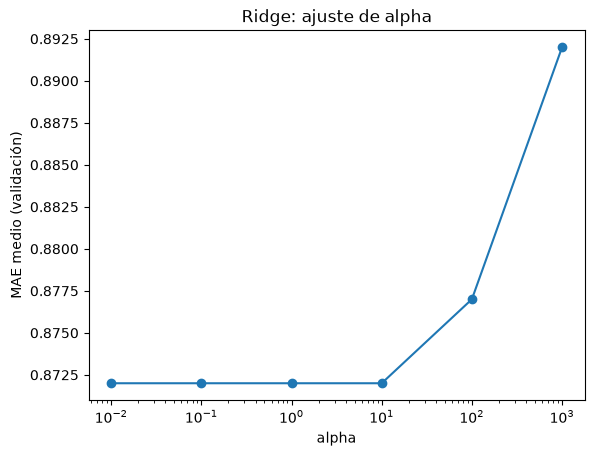

In [106]:
plt.plot(ajuste_alpha["alpha"], ajuste_alpha["MAE_medio"], marker="o")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("MAE medio (validación)")
plt.title("Ridge: ajuste de alpha")
plt.show()

Configuración final del modelo Ridge(ratio):

In [107]:
filas = []
modelo_ridge.set_params(ridge__alpha=1.0)
for mes in MESES_VALIDACION:
    train, valid = obtener_fold(df, mes) # separar los datos
    
    modelo_ridge.fit(train, train[OBJETIVO]) # usando el pipeline con el modelo en train: APRENDER
    pred = modelo_ridge.predict(valid) # usando el pipeline con el modelo en validación: PREDECIR

    filas.append({"bloque": f"valid {mes}",
                  "n_train": len(train),
                  **metricas(valid[OBJETIVO], pred)})

resultados_ridge = pd.DataFrame(filas).round(3)
print(resultados_ridge)
print("\nMAE medio: ", resultados_ridge["MAE"].mean().round(3))
print("RMSE medio:", resultados_ridge["RMSE"].mean().round(3))

          bloque  n_train    MAE   RMSE    n
0  valid 2026-02     8940  0.938  1.322  919
1  valid 2026-03     9859  0.832  1.201  997
2  valid 2026-04    10856  0.844  1.209  971

MAE medio:  0.871
RMSE medio: 1.244


Resultados (objetivo: ratio)

Se ha entrenado y validado Ridge en los 3 folds temporales (febrero, marzo y abril de 2026). En cada fold el modelo se entrena desde cero con los meses anteriores al de validación.

**Ajuste de alpha**

Se han probado seis valores de alpha, cada uno 10 veces mayor que el anterior, usando los mismos 3 folds. El criterio de elección es el menor MAE medio.

- Entre 0,01 y 10 el MAE medio se mantiene constante (0,872). Las diferencias por fold son de milésimas.
- A partir de 100 el error empieza a subir, hasta 0,892 con alpha = 1.000. Con tanta penalización el modelo pierde información de las variables.

El modelo es robusto a la elección de alpha dentro de la meseta. Se adopta **alpha = 1**, valor central de la meseta.

El error es bastante estable entre folds. Marzo y abril dan valores muy parecidos. Febrero es el fold con más error, y también el que entrena con menos meses. Con los datos disponibles no se puede saber si la diferencia se debe al menor volumen de entrenamiento o a algo propio de ese mes.

El RMSE sigue siendo claramente mayor que el MAE (relación ≈ 1,43). Esto indica que se mantienen errores grandes en una parte de las fases, en línea con la cola del ratio vista en el análisis de la variable objetivo.



### 4. Entrenar y validar con los 3 folds (log(ratio))

Ahora trabajando con el ratio es importante trabajar en la misma escala a la hora de comparar. El ratio que devuelva el modelo devera aplicarse el exponente para pasarlo a la misma escala del ratio.

ratio - log → log(ratio) → Ridge aprende (train) - Ridge predice (valid) → exp → ratio predicho 

In [108]:
ALPHAS = [0.01, 0.1, 1, 10, 100, 1000]

filas = []
for alpha in ALPHAS:
    modelo_ridge.set_params(ridge__alpha=alpha)

    maes, rmses = [], []
    for mes in MESES_VALIDACION:
        train, valid = obtener_fold(df, mes) # separar los datos
        modelo_ridge.fit(train, np.log(train[OBJETIVO])) # usando el pipeline con el modelo en train: APRENDER
        pred = np.exp(modelo_ridge.predict(valid)) # usando el pipeline con el modelo en validación: PREDECIR

        # guardar las metricas
        m = metricas(valid[OBJETIVO], pred)
        maes.append(m["MAE"])
        rmses.append(m["RMSE"])

    filas.append({"alpha": alpha,
                  "MAE_medio": np.mean(maes),
                  "RMSE_medio": np.mean(rmses),
                  "MAE_por_fold": np.round(maes, 3)})

ajuste_alpha = pd.DataFrame(filas).round(3)
print(ajuste_alpha)

     alpha  MAE_medio  RMSE_medio           MAE_por_fold
0     0.01      0.852       1.312  [0.922, 0.809, 0.823]
1     0.10      0.852       1.312  [0.922, 0.809, 0.823]
2     1.00      0.852       1.312   [0.923, 0.81, 0.823]
3    10.00      0.853       1.314  [0.925, 0.812, 0.822]
4   100.00      0.859       1.325  [0.931, 0.819, 0.827]
5  1000.00      0.880       1.360  [0.945, 0.844, 0.853]


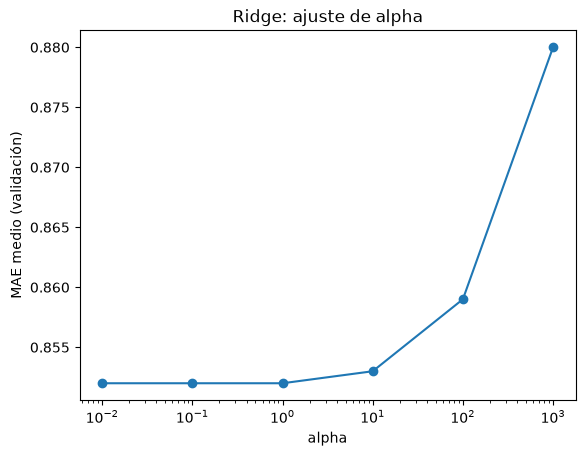

In [109]:
plt.plot(ajuste_alpha["alpha"], ajuste_alpha["MAE_medio"], marker="o")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("MAE medio (validación)")
plt.title("Ridge: ajuste de alpha")
plt.show()

Ahora tambien para cada versión del modelo se han probado seis valores de alpha, cada uno 10 veces mayor que el anterior. Se han usado los mismos 3 folds temporales en ambas versiones. El criterio de elección es el menor MAE medio en validación.

Las dos versiones muestran el mismo comportamiento. Para valores bajos de alpha el MAE medio se mantiene prácticamente constante: forma una meseta. A partir de alpha = 100 el error aumenta. Con tanta penalización el modelo pierde parte de la información de las variables.

El comportamiento se repite en los 3 folds, así que la elección no depende de un mes concreto.

Se adopta **alpha = 1** en ambas versiones. Es un valor situado dentro de la meseta, donde el error es mínimo. Usar el mismo alpha en las dos versiones permite que la única diferencia entre ellas sea la variable objetivo.

Los resultados indican que el modelo es robusto a la elección de alpha: dentro de la meseta, las diferencias de MAE son de milésimas.

Modelo final con Ridge(log(ratio)):

In [110]:
filas = []
modelo_ridge.set_params(ridge__alpha=1.0)
for mes in MESES_VALIDACION:
    train, valid = obtener_fold(df, mes) # separar los datos
    
    modelo_ridge.fit(train, np.log(train[OBJETIVO])) # usando el pipeline con el modelo en train: APRENDER
    pred = np.exp(modelo_ridge.predict(valid)) # usando el pipeline con el modelo en validación: PREDECIR

    filas.append({"bloque": f"valid {mes}",
                  "n_train": len(train),
                  **metricas(valid[OBJETIVO], pred)})

resultados_ridge_log = pd.DataFrame(filas).round(3)
print(resultados_ridge_log)
print("\nMAE medio: ", resultados_ridge_log["MAE"].mean().round(3))
print("RMSE medio:", resultados_ridge_log["RMSE"].mean().round(3))

          bloque  n_train    MAE   RMSE    n
0  valid 2026-02     8940  0.923  1.394  919
1  valid 2026-03     9859  0.810  1.263  997
2  valid 2026-04    10856  0.823  1.279  971

MAE medio:  0.852
RMSE medio: 1.312


El modelo se ha entrenado con log(ratio) y alpha = 1. Las predicciones se han devuelto a escala ratio con la exponencial antes de calcular las métricas. Así los resultados se pueden comparar directamente con los de la versión ratio.

El error es estable entre folds. Marzo y abril dan valores muy parecidos. Febrero vuelve a ser el fold con más error, igual que en la versión ratio.

La relación RMSE/MAE es de 1,54. Se mantienen errores grandes en una parte de las fases.

A tener en cuenta: al deshacer el logaritmo con la exponencial, la predicción tiende a situarse cerca de la mediana y no de la media. Esto puede favorecer al MAE y penalizar al RMSE. Se valorará en la comparación entre versiones.

### 5. Comparar con Baseline

In [111]:
b0 = pd.read_parquet("predicciones/b0.parquet") # predicciones B0

filas = []
for i, mes in enumerate(MESES_VALIDACION):
    _, valid_b0 = obtener_fold(b0, mes)
    m_b0 = metricas(valid_b0["ratio"], valid_b0["pred_B0"])

    filas.append({
        "fold":             mes,
        "MAE_B0":           m_b0["MAE"],
        "MAE_ratio":        resultados_ridge.loc[i, "MAE"],
        "MAE_log(ratio)":   resultados_ridge_log.loc[i, "MAE"],
        "RMSE_B0":          m_b0["RMSE"],
        "RMSE_ratio":       resultados_ridge.loc[i, "RMSE"],
        "RMSE_log":         resultados_ridge_log.loc[i, "RMSE"],
    })

comparacion = pd.DataFrame(filas)
comparacion.loc["media"] = comparacion.iloc[:, 1:].mean()

# Mejora respecto a B0 (%), en MAE
comparacion["mejora_MAE_ratio_%"] = (1 - comparacion["MAE_ratio"] / comparacion["MAE_B0"]) * 100
comparacion["mejora_MAE_log(ratio)_%"]   = (1 - comparacion["MAE_log(ratio)"]   / comparacion["MAE_B0"]) * 100

display(comparacion.round(3))

,fold,MAE_B0,MAE_ratio,MAE_log(ratio),RMSE_B0,RMSE_ratio,RMSE_log,mejora_MAE_ratio_%,mejora_MAE_log(ratio)_%
0,2026-02,1.144,0.938,0.923,1.794,1.322,1.394,18.031,19.341
1,2026-03,1.083,0.832,0.810,1.669,1.201,1.263,23.176,25.208
2,2026-04,1.099,0.844,0.823,1.696,1.209,1.279,23.207,25.118
media,NaN,1.109,0.871,0.852,1.720,1.244,1.312,21.416,23.160


Viendo la comparación, las dos versiones mejoran B0 en los 3 folds.     

En MAE (métrica principal), log(ratio) gana a ratio en los 3 folds, por pocas centesimas.

En RMSE ocurre lo contrario: ratio gana a log(ratio) en los 3 folds.

### 6. Guardar predicciones

In [114]:
modelo_ridge.set_params(ridge__alpha=1.0)

partes = []
for mes in MESES_VALIDACION:
    train, valid = obtener_fold(df, mes)

    # Versión ratio
    modelo_ridge.fit(train, train[OBJETIVO])
    pred_ratio = modelo_ridge.predict(valid)

    # Versión log(ratio)
    modelo_ridge.fit(train, np.log(train[OBJETIVO]))
    pred_log = np.exp(modelo_ridge.predict(valid))

    partes.append(pd.DataFrame({
        "IDMOTask":         valid["IDMOTask"].values,
        "mes_orden":        valid["mes_orden"].values,
        "ratio":            valid[OBJETIVO].values,
        "pred_ridge_ratio": pred_ratio,
        "pred_ridge_log":   pred_log,
    }))

pred_ridge_valid = pd.concat(partes, ignore_index=True)
pred_ridge_valid.to_parquet("predicciones/ridge_valid.parquet", index=False)

print(pred_ridge_valid.shape)
display(pred_ridge_valid.head())

(2887, 5)


,IDMOTask,mes_orden,ratio,pred_ridge_ratio,pred_ridge_log
0,503758e9-3758-40dc-8b3f-fca57d71de65,2026-02,0.577435,2.184681,1.824281
1,89527791-13b3-45d8-826a-dd93ee1b37e8,2026-02,0.877084,2.548645,2.035497
2,1722d5f7-ebef-41e4-aec3-26b2a7e98a25,2026-02,3.017857,1.896370,1.495517
3,7dd63da0-13f4-42ad-82bf-33ac3650ac3e,2026-02,1.947847,1.197093,1.064345
4,6bffabd3-318b-4244-b70a-f832e9c13c1d,2026-02,1.354938,1.376409,1.246473


In [122]:
media_ratio = pred_ridge_valid["pred_ridge_ratio"].mean()
media_log   = pred_ridge_valid["pred_ridge_log"].mean()
media_real  = pred_ridge_valid["ratio"].mean()

mediana_ratio = pred_ridge_valid["pred_ridge_ratio"].median()
mediana_log   = pred_ridge_valid["pred_ridge_log"].median()
mediana_real  = pred_ridge_valid["ratio"].median()

print(f"Media predicción ratio: {media_ratio:.3f}")
print(f"Media predicción log:   {media_log:.3f}")
print(f"Media ratio real:       {media_real:.3f}")
print("-"*35)
print(f"Mediana predicción ratio: {mediana_ratio:.3f}")
print(f"Mediana predicción log:   {mediana_log:.3f}")
print(f"Mediana ratio real:       {mediana_real:.3f}")



Media predicción ratio: 1.880
Media predicción log:   1.574
Media ratio real:       1.971
-----------------------------------
Mediana predicción ratio: 1.876
Mediana predicción log:   1.521
Mediana ratio real:       1.550


El prototipo está pensado para estimar la desviación de cada fase de forma individual. Por este motivo, el MAE se considera la métrica principal: mide cuánto se equivoca el modelo en la fase típica.

Con este criterio, la versión log(ratio) ofrece el mejor resultado. Sin embargo, sus predicciones se sitúan cerca de la mediana del ratio y no de su media: la media de sus predicciones (1,57) queda por debajo del ratio medio real (1,97). 